In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# LOAD DATASETS

In [2]:
train = pd.read_csv("training_image_features_1.csv")
validation = pd.read_csv("validation_image_features_1.csv")
test = pd.read_csv("testing_image_features_1.csv")

# Combine datasets
df = pd.concat([train, validation, test], ignore_index=True)

# Seaborn appearance
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# 1. SCATTER PLOT
# Damage Score vs Condition Score

SCORE DETAILS
Pearson Correlation: -0.9994
R² Score: 0.9988


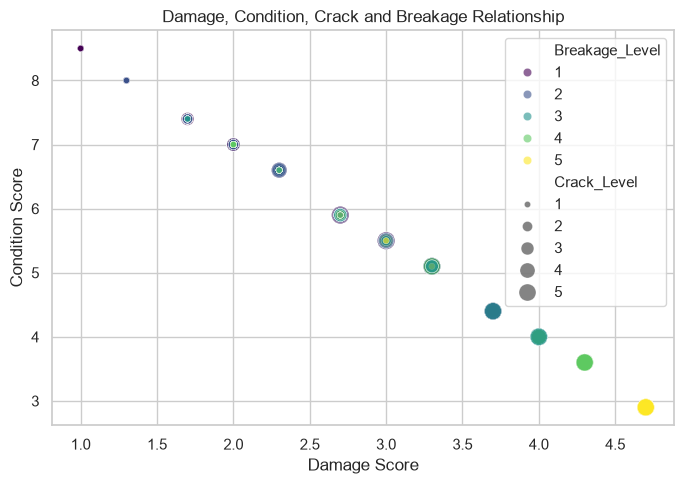

In [3]:
train = pd.read_csv("training_image_features.csv")
validation = pd.read_csv("validation_image_features.csv")
test = pd.read_csv("testing_image_features.csv")

df = pd.concat([train, validation, test], ignore_index=True)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Damage_Score",
    y="Condition_Score",
    size="Crack_Level",
    hue="Breakage_Level",
    alpha=0.6,
    sizes=(20, 150),
    palette="viridis"
)

plt.title("Damage, Condition, Crack and Breakage Relationship")
plt.xlabel("Damage Score")
plt.ylabel("Condition Score")

plt.tight_layout()
plt.savefig(
    "damage_condition_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
correlation = df["Damage_Score"].corr(df["Condition_Score"])

print("SCORE DETAILS")
print("Pearson Correlation:", round(correlation, 4))
print("R² Score:", round(correlation ** 2, 4))
plt.show()


# 2. HISTOGRAM
# Damage Score Distribution

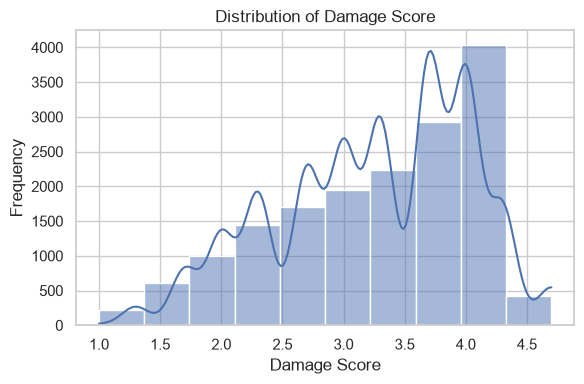

In [4]:
plt.figure(figsize=(6, 4))

sns.histplot(
    data=df,
    x="Damage_Score",
    bins=10,
    kde=True
)

plt.title("Distribution of Damage Score")
plt.xlabel("Damage Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(
    "2_damage_score_histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 3. BOX PLOT
# Damage Score

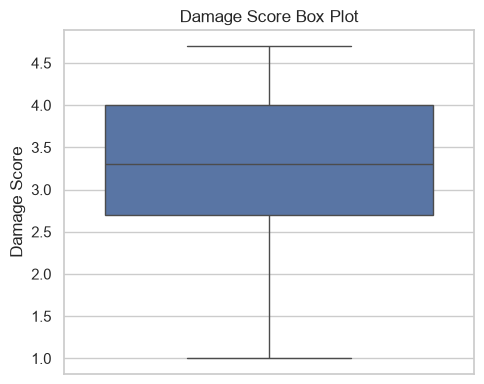

In [5]:
plt.figure(figsize=(5, 4))

sns.boxplot(
    data=df,
    y="Damage_Score"
)

plt.title("Damage Score Box Plot")
plt.ylabel("Damage Score")

plt.tight_layout()
plt.savefig(
    "3_damage_score_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 4. BAR CHART
# Material Type

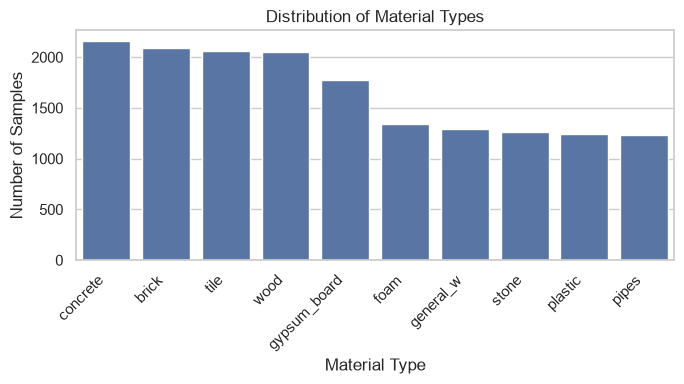

In [6]:

material_order = df["Material_Type"].value_counts().index

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Material_Type",
    order=material_order
)

plt.title("Distribution of Material Types")
plt.xlabel("Material Type")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    "4_material_type_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. CONDITION CLASS

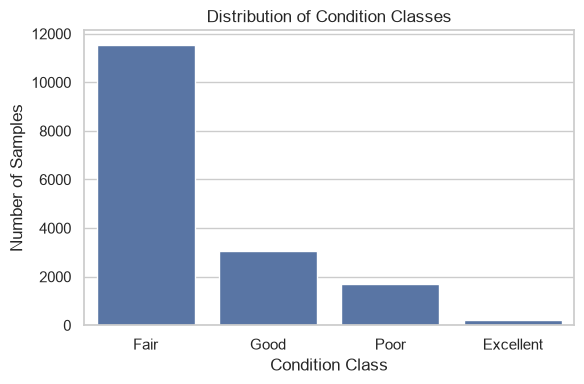

In [7]:
plt.figure(figsize=(6, 4))

condition_order = df["Condition_Class"].value_counts().index

sns.countplot(
    data=df,
    x="Condition_Class",
    order=condition_order
)

plt.title("Distribution of Condition Classes")
plt.xlabel("Condition Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.savefig(
    "5_condition_class_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 6. PIE CHART - CONDITION CLASS


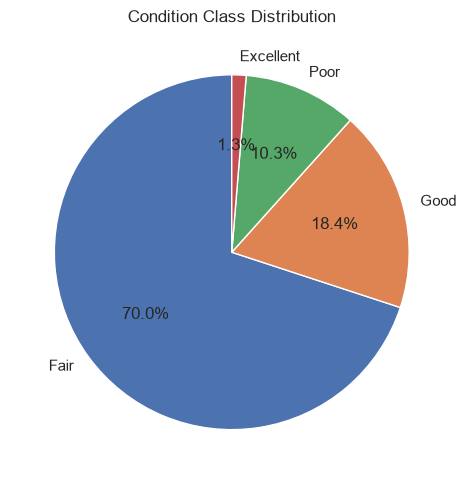

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

condition_counts = df["Condition_Class"].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    condition_counts.values,
    labels=condition_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Condition Class Distribution")

plt.tight_layout()
plt.savefig(
    "5_condition_class_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 7. SUPPORT VECTOR MACHINES

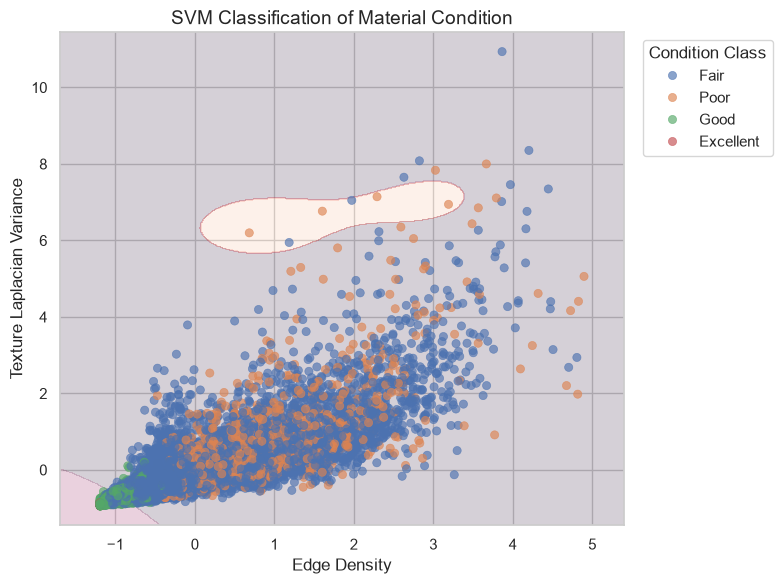

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

features = [
    "edge_density",
    "texture_laplacian_var"
]

X_train = train[features]
X_test = test[features]

encoder = LabelEncoder()
y_train = encoder.fit_transform(
    train["Condition_Class"]
)
y_test = encoder.transform(
    test["Condition_Class"]
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm.fit(X_train_scaled, y_train)


x_min = X_train_scaled[:, 0].min() - 0.5
x_max = X_train_scaled[:, 0].max() + 0.5

y_min = X_train_scaled[:, 1].min() - 0.5
y_max = X_train_scaled[:, 1].max() + 0.5

xx, yy = __import__("numpy").meshgrid(
    __import__("numpy").linspace(x_min, x_max, 500),
    __import__("numpy").linspace(y_min, y_max, 500)
)

grid = __import__("numpy").c_[
    xx.ravel(),
    yy.ravel()
]

Z = svm.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))


plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.20,
    levels=len(encoder.classes_) - 1
)

sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=encoder.inverse_transform(y_train),
    palette="deep",
    s=35,
    alpha=0.65,
    edgecolor=None
)

plt.title(
    "SVM Classification of Material Condition",
    fontsize=14
)

plt.xlabel("Edge Density")
plt.ylabel("Texture Laplacian Variance")

plt.legend(
    title="Condition Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "svm_classification_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()